In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from influxdb_client import InfluxDBClient

load_dotenv()

INFLUX_URL = os.getenv("INFLUX_URL", "http://localhost:8086")
INFLUX_TOKEN = os.getenv("INFLUX_TOKEN")
INFLUX_ORG = os.getenv("INFLUX_ORG", "casa")
INFLUX_BUCKET = os.getenv("INFLUX_BUCKET", "monitoraggio_pi")


if not INFLUX_TOKEN:
    print("Errore: INFLUX_TOKEN non trovato! WTF .env.")
else:
    print(f" Configurazione caricata correttamente!")
    print(f" URL: {INFLUX_URL} |  Bucket: {INFLUX_BUCKET}")
    
# Inizializza il client
client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
query_api = client.query_api()

# query Flux (prendiamo l'ultima ora di dati)
query = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -1h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
'''

df = query_api.query_data_frame(query)

# Chiudi la connessione
client.close()

df.head()


 Configurazione caricata correttamente!
 URL: http://10.26.169.209:8086 |  Bucket: monitoraggio_pi


/home/linkyolo/anaconda3/lib/python3.13/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "monitoraggio_pi")
  |> range(start: -1h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/influxdata/influxdb/schema/fieldsascols/

  warnings.warn(message, MissingPivotFunction)


,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza
0,_result,0,2026-07-08 16:07:55.148256+00:00,2026-07-08 17:07:55.148256+00:00,2026-07-08 16:22:01.165245+00:00,33.2,percepita,ambiente,raspberry_pi_4,camera
1,_result,0,2026-07-08 16:07:55.148256+00:00,2026-07-08 17:07:55.148256+00:00,2026-07-08 16:22:06.429829+00:00,33.2,percepita,ambiente,raspberry_pi_4,camera
2,_result,0,2026-07-08 16:07:55.148256+00:00,2026-07-08 17:07:55.148256+00:00,2026-07-08 16:22:11.701558+00:00,33.2,percepita,ambiente,raspberry_pi_4,camera
3,_result,0,2026-07-08 16:07:55.148256+00:00,2026-07-08 17:07:55.148256+00:00,2026-07-08 16:22:16.963743+00:00,33.2,percepita,ambiente,raspberry_pi_4,camera
4,_result,0,2026-07-08 16:07:55.148256+00:00,2026-07-08 17:07:55.148256+00:00,2026-07-08 16:22:22.235548+00:00,33.2,percepita,ambiente,raspberry_pi_4,camera


In [9]:
df.count()

result          1527
table           1527
_start          1527
_stop           1527
_time           1527
_value          1527
_field          1527
_measurement    1527
host            1527
stanza          1527
dtype: int64

--- Statistiche Temperatura ---
count    509.000000
mean      35.096660
std        0.296981
min       34.200000
25%       35.100000
50%       35.200000
75%       35.200000
max       35.500000
Name: _value, dtype: float64


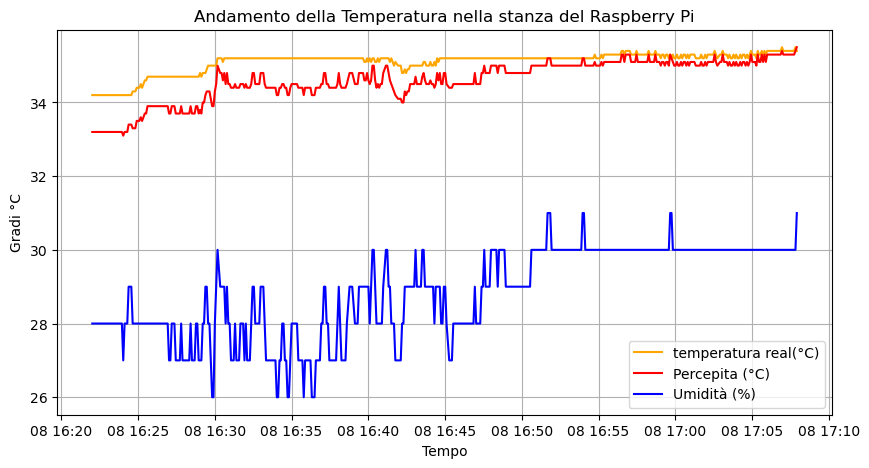

In [10]:

df_temp = df[df['_field'] == 'temperatura']
df_temp_percepita = df[df['_field'] == 'percepita']
df_umidita= df[df['_field'] == 'umidita']

df_temp = df_temp.set_index('_time')

# (Media, Min, Max, Deviazione Standard)
print("--- Statistiche Temperatura ---")
print(df_temp['_value'].describe())

plt.figure(figsize=(10, 5))
plt.plot(df_temp.index, df_temp['_value'], label='temperatura real(°C)', color='orange')
plt.plot(df_temp.index, df_temp_percepita['_value'], label='Percepita (°C)', color='red')
plt.plot(df_temp.index, df_umidita['_value'], label='Umidità (%)', color='blue')
plt.title('Andamento della Temperatura nella stanza del Raspberry Pi')
plt.xlabel('Tempo')
plt.ylabel('Gradi °C')
plt.grid(True)
plt.legend()
plt.show()


In [11]:
df.to_csv("test_export.csv")

In [ ]:
#TODO: vedere pivot() tra flux query e dataframe